In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import pickle
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

In [ ]:
BASE = "/content/drive/MyDrive/nuralproject"

CSV_PATH = f"{BASE}/dataset_caption.csv"
IMG_FEAT_PATH = f"{BASE}/efficient_features_map.npy"

SAVE_DIR = f"{BASE}/models/LSTM"
os.makedirs(SAVE_DIR, exist_ok=True)


In [ ]:

df = pd.read_csv(CSV_PATH)
df = df.dropna()

df["answer"] = df["answer"].str.lower().str.strip()
df["image"] = df["image"].str.strip()

print(df.head())

              image                       question  \
0  images/img_0.jpg  what does the image describe?   
1  images/img_1.jpg  what does the image describe?   
2  images/img_2.jpg  what does the image describe?   
3  images/img_3.jpg  what does the image describe?   
4  images/img_4.jpg  what does the image describe?   

                                              answer      type  
0                dog running on beach during daytime  describe  
1                   black and white short coated dog  describe  
2     long-coated black and white dog during daytime  describe  
3  yellow labrador retriever biting yellow tulip ...  describe  
4  shallow focus photography of white shih tzu pu...  describe  


In [ ]:
REMOVE_WORDS = [
    "photo of", "image of", "picture of",
    "closeup", "close up",
    "photography of",
    "shallow focus", "selective focus",
    "landscape photography of",
    "during daytime", "during night",
    "on top of"
]

def clean_caption(text):
    text = text.lower().strip()
    for w in REMOVE_WORDS:
        text = text.replace(w, "")
    text = text.replace("-", " ")
    text = text.replace(".", "")
    text = text.replace(",", "")
    text = text.replace("'s", "")
    return " ".join(text.split())


df["answer"] = df["answer"].apply(clean_caption)  #ne3ml kda 3la kol el answers


In [ ]:
#sentence → words
def tokenize(t):
    return t.split()

counter = Counter()
for cap in df["answer"]:
    counter.update(tokenize(cap))
#Special Tokens
vocab = {
    "<pad>": 0,
    "<start>": 1,
    "<end>": 2,
    "<unk>": 3
}
#Build Word Dictionary
idx = 4
for w in counter:
    vocab[w] = idx
    idx += 1
#rev map
idx2word = {v:k for k,v in vocab.items()}

print("Vocab size:", len(vocab))

Vocab size: 324


In [ ]:
def encode(text):
    tokens = tokenize(text)
    return torch.tensor([
        vocab["<start>"]
    ] + [vocab.get(w, vocab["<unk>"]) for w in tokens] + [vocab["<end>"]])

encoded = [encode(c) for c in df["answer"]]  #all

padded_caps = pad_sequence(encoded, batch_first=True, padding_value=0) #same len
print("Captions shape:", padded_caps.shape)

Captions shape: torch.Size([195, 18])


In [ ]:

img_features = np.load(IMG_FEAT_PATH)
img_features = img_features[:len(df)]

print("Image features:", img_features.shape)

Image features: (195, 49, 1280)


In [ ]:
#DataLoader
class CaptionDataset(Dataset):
    def __init__(self, imgs, caps):
        self.imgs = torch.tensor(imgs).float()
        self.caps = caps

    def __len__(self):
        return len(self.caps)

    def __getitem__(self, idx):  # image_features,caption
        return self.imgs[idx], self.caps[idx]


loader = DataLoader(
    CaptionDataset(img_features, padded_caps),
    batch_size=32,   #steps
    shuffle=True
)

In [ ]:
class CleanAttentionLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        img_dim=1280,
        embed_dim=256,
        hidden_dim=512, #balance
        num_heads=8
    ):

        super().__init__()

        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim  #len 256
        )

        self.dropout = nn.Dropout(0.3)

        # image projection
        self.img_fc = nn.Linear(
            img_dim,
            hidden_dim
        )

        # MULTI-HEAD ATTENTION
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            batch_first=True
        )

        # LSTM
        self.lstm = nn.LSTM(
            embed_dim + hidden_dim,
            hidden_dim,
            batch_first=True
        )
        #pro
        self.fc = nn.Linear(
            hidden_dim,
            vocab_size
        )

    def forward(self, img, caps):

        B = img.size(0)

        # [B,H] ,features projection
        img_feat = self.img_fc(img)


        h = torch.zeros(1,B,self.hidden_dim).to(img.device)
        c = torch.zeros( 1,B,self.hidden_dim).to(img.device)


        emb = self.embedding(caps)  #
        emb = self.dropout(emb)  #overfitting.


        outputs = []

        for t in range(emb.size(1)): #for text

            # [B,E]
            word = emb[:, t, :]

            # QUERY = hidden state
            # [B,1,H]
            query = h[-1].unsqueeze(1)

            # multi-head attention
            context, attn_weights = self.attention(
                query=query,
                key=img_feat,
                value=img_feat
            )

            # [B,H]
            context = context.squeeze(1)

            # concat word + context
            lstm_in = torch.cat([word, context],dim=1).unsqueeze(1)


            out, (h, c) = self.lstm(lstm_in,(h, c) )

            logits = self.fc( out.squeeze(1) )

            outputs.append(logits)

        return torch.stack(outputs, dim=1)

In [41]:

#  TRAIN


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CleanAttentionLSTM(len(vocab)).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=0.0005)

best_loss = float("inf")
patience = 10
counter = 0
teacher_ratio = 0.9

for epoch in range(40):

    model.train()
    total_loss = 0

    teacher_ratio = max(0.5, teacher_ratio * 0.95)

    for imgs, caps in loader:

        imgs, caps = imgs.to(device), caps.to(device)
        #reset gradients
        optimizer.zero_grad()

        out = model(imgs, caps[:, :-1])

        loss = criterion(
            out.reshape(-1, len(vocab)),
            caps[:, 1:].reshape(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
        #update weight
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Teacher: {teacher_ratio:.2f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        counter = 0
        torch.save(model.state_dict(), f"{SAVE_DIR}/lstm_attn.pth")
        print("Saved best model")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break





Epoch 1 | Loss: 5.5443 | Teacher: 0.85
Saved best model
Epoch 2 | Loss: 4.7946 | Teacher: 0.81
Saved best model
Epoch 3 | Loss: 4.6424 | Teacher: 0.77
Saved best model
Epoch 4 | Loss: 4.4997 | Teacher: 0.73
Saved best model
Epoch 5 | Loss: 4.3840 | Teacher: 0.70
Saved best model
Epoch 6 | Loss: 4.2006 | Teacher: 0.66
Saved best model
Epoch 7 | Loss: 4.0476 | Teacher: 0.63
Saved best model
Epoch 8 | Loss: 3.6778 | Teacher: 0.60
Saved best model
Epoch 9 | Loss: 3.7579 | Teacher: 0.57
Epoch 10 | Loss: 3.4606 | Teacher: 0.54
Saved best model
Epoch 11 | Loss: 3.2767 | Teacher: 0.51
Saved best model
Epoch 12 | Loss: 3.0997 | Teacher: 0.50
Saved best model
Epoch 13 | Loss: 2.9203 | Teacher: 0.50
Saved best model
Epoch 14 | Loss: 2.7328 | Teacher: 0.50
Saved best model
Epoch 15 | Loss: 2.6142 | Teacher: 0.50
Saved best model
Epoch 16 | Loss: 2.4749 | Teacher: 0.50
Saved best model
Epoch 17 | Loss: 2.3944 | Teacher: 0.50
Saved best model
Epoch 18 | Loss: 2.2966 | Teacher: 0.50
Saved best model


In [46]:
def generate(img_feat):

    model.eval()

    # 1) ensure tensor + correct shape
    img_feat = torch.tensor(img_feat).float().to(device)

    # lazm (49, 1280)
    if img_feat.dim() == 3:
        img_feat = img_feat.squeeze(0)

    # 2) project image features
    img_context = model.img_fc(img_feat)   # (49, H)

    # add batch dimension → (1, 49, H)
    img_context = img_context.unsqueeze(0)

    # 3) init LSTM states
    h = torch.zeros(1, 1, model.hidden_dim).to(device)
    c = torch.zeros(1, 1, model.hidden_dim).to(device)

    # 4) start token
    word = torch.tensor([[vocab["<start>"]]]).to(device)

    caption = []

    for _ in range(20):

        # word embedding → (1, embed_dim)
        emb = model.embedding(word)

        # query from hidden state → (1, 1, H)
        query = h[-1].unsqueeze(1)

        # attention
        context, _ = model.attention(
            query=query,
            key=img_context,
            value=img_context
        )

        # (1, H)
        context = context.squeeze(1)

        # concat word + context
        lstm_in = torch.cat(
            [emb.squeeze(1), context],
            dim=1
        ).unsqueeze(1)

        # LSTM step
        out, (h, c) = model.lstm(lstm_in, (h, c))

        logits = model.fc(out.squeeze(1))

        pred = logits.argmax(1).item()

        if pred == vocab["<end>"]:
            break

        caption.append(idx2word[pred])

        word = torch.tensor([[pred]]).to(device)

    return " ".join(caption)

In [47]:
model.load_state_dict(torch.load(f"{SAVE_DIR}/lstm_attn.pth", map_location=device))
model.to(device)
model.eval()
print("Model loaded")

Model loaded


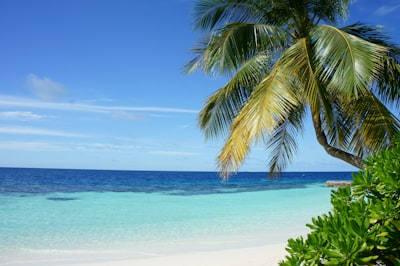

REAL: coconut tree near body of water
PRED:
aerial view boats on seashore


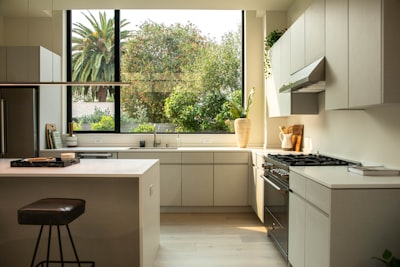

REAL: white and black gas range oven
PRED:
brown wooden cabinet near green and white table


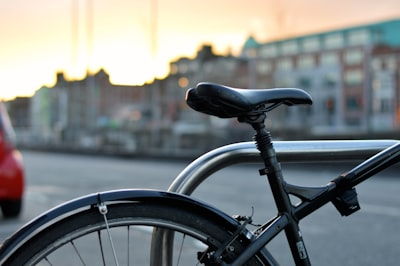

REAL: black mountain bike parked near the road
PRED:
black road bike parked near the road


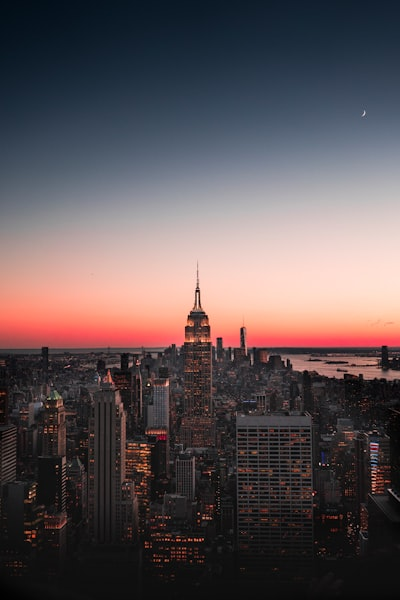

REAL: empire state building new york at night
PRED:
aerial high rise building


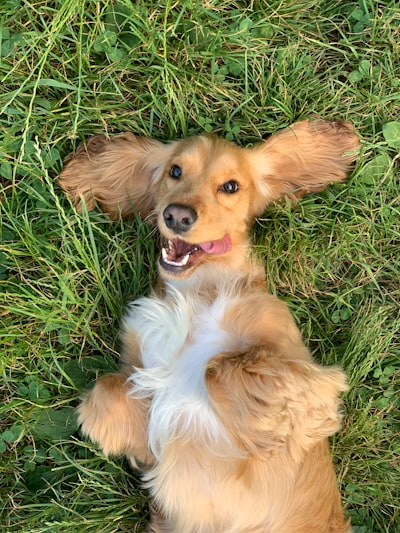

REAL: brown and white long coated small dog lying on green grass
PRED:
brown and white long coated small dog


In [49]:
import random
from IPython.display import display, Image as IPImage

IMAGES_DIR = f"{BASE}/images"

for _ in range(5):

    idx = random.randint(0, len(df)-1)

    img_path = os.path.join(
        IMAGES_DIR,
        os.path.basename(df.iloc[idx]["image"])
    )

    # show image
    display(IPImage(filename=img_path, width=300))

    print("REAL:", df.iloc[idx]["answer"])

    print("PRED:")

    pred_caption = generate(img_features[idx])

    print(pred_caption)

    print("="*60)